In [11]:
from spectral_core import (
    SpectralDataset,
    PLSRComponents,
    compute_metrics
)

In [12]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.cross_decomposition import PLSRegression

In [13]:
DATA_DIR = Path('../data/processed/')
MODEL_DIR = Path('../data/models/')
FIGURE_DIR = Path('../data/figures/')

MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [14]:
train = SpectralDataset.from_npy(
    spectra_path=DATA_DIR / 'X_train.npy',
    wavenumbers_path=DATA_DIR / 'wavenumbers.npy',
    features_paths={'HbA1c': DATA_DIR / 'y_train.npy'}
)

val = SpectralDataset.from_npy(
    spectra_path=DATA_DIR / 'X_val.npy',
    wavenumbers_path=DATA_DIR / 'wavenumbers.npy',
    features_paths={'HbA1c': DATA_DIR / 'y_val.npy'}
)

test = SpectralDataset.from_npy(
    spectra_path=DATA_DIR / 'X_test.npy',
    wavenumbers_path=DATA_DIR / 'wavenumbers.npy',
    features_paths={'HbA1c': DATA_DIR / 'y_test.npy'}
)

In [15]:
calibration = SpectralDataset.from_arrays(
    spectra=np.vstack([train.spectra, val.spectra]),
    wavenumbers=train.wavenumbers,
    features={
        'HbA1c': np.concatenate([
            train.features['HbA1c'],
            val.features['HbA1c']
        ])
    }
)

In [16]:
X_cal, y_cal = calibration.spectra, calibration.features['HbA1c']
X_test, y_test = test.spectra, test.features['HbA1c']

X_cal.shape, X_test.shape

((538, 3319), (135, 3319))

In [17]:
calibration.summary()

### Spectral Dataset Summary
- **Samples:** 538
- **Features:** 3319 wavenumbers
- **Range:** 800.3 - 3399.9 cm⁻¹

,Mean,Std,Min,Max
HbA1c,7.306208,2.340882,3.8,14.0


In [18]:
model = PLSRComponents(target_name='HbA1c')

n_components = model.fit(X_cal, y_cal, ncomp=20, cv=10)
n_components

9

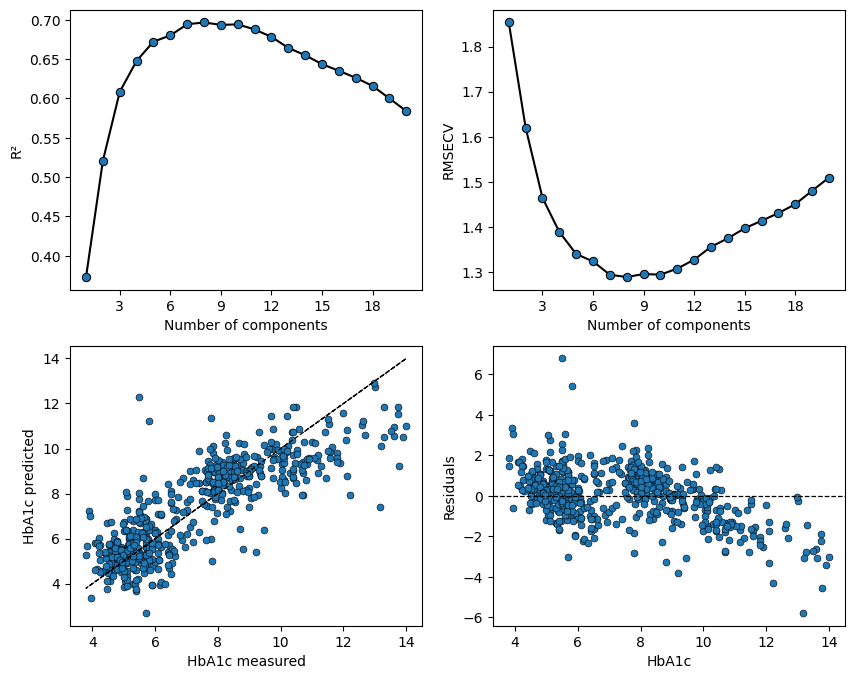

In [19]:
fig, axs = model.plot_cv_results()
fig.savefig(FIGURE_DIR / 'figure_plsr_cv.png', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / 'figure_plsr_cv.pdf', bbox_inches='tight')

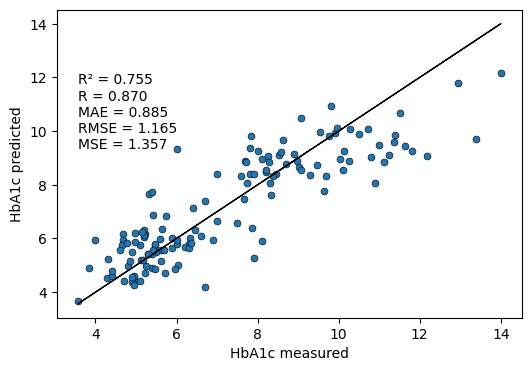

In [20]:
fig, ax = model.evaluate(X_test, y_test)
fig.savefig(FIGURE_DIR / 'figure_plsr_test.png', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / 'figure_plsr_test.pdf', bbox_inches='tight')

In [ ]:
rmsecv = np.array(model.rmses)
components = np.arange(1, len(rmsecv) + 1)

print(f'selected {n_components} components (lowest RMSECV)')
print('  ' + '  '.join(f'{k}:{v:.4f}' for k, v in zip(components[:12], rmsecv[:12])))

In [ ]:
neighbourhood = []
for count in range(max(1, n_components - 3), min(len(rmsecv), n_components + 3) + 1):
    fitted = PLSRegression(n_components=count).fit(X_cal, y_cal)
    neighbourhood.append({
        'n_components': count,
        'rmsecv': rmsecv[count - 1],
        **compute_metrics(y_test, fitted.predict(X_test))
    })

pd.DataFrame(neighbourhood)

In [ ]:
joblib.dump(
    {
        'model': model.get_fitted_model(),
        'n_components': n_components,
        'wavenumbers': calibration.wavenumbers
    },
    MODEL_DIR / 'plsr_hba1c.joblib'
)